# Prophet Forecasting — Accident Count Prediction
---
**Goal:** Predict future accident counts for next 12 months  
**Model:** Facebook Prophet (Time Series Forecasting)  
**Input:** Gold_Layer/US_Accidents_Gold_Modeling.csv  
**Output:** forecast_results.csv + Dashboard 7 data

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
import warnings
warnings.filterwarnings('ignore')

MAIN_GRAY  = "#696969"
LIGHT_GRAY = "#a9a9a9"
print("Libraries imported")

Libraries imported


## 2. Load & Prepare Data

In [2]:
df = pd.read_csv("Gold_Layer/US_Accidents_Gold_Modeling.csv")

# Prophet needs: ds (date) + y (value)
df['Start_Date'] = pd.to_datetime(df['Year'].astype(str) + '-' +
                                   df['Month'].astype(str).str.zfill(2) + '-01')

# Monthly accident counts
monthly = df.groupby('Start_Date').size().reset_index(name='count')
monthly.columns = ['ds', 'y']
monthly = monthly.sort_values('ds').reset_index(drop=True)

print(f"Time range: {monthly['ds'].min().date()} to {monthly['ds'].max().date()}")
print(f"Total months: {len(monthly)}")
print(f"Avg accidents/month: {monthly['y'].mean():,.0f}")
monthly.tail(6)

Time range: 2016-01-01 to 2023-03-01
Total months: 87
Avg accidents/month: 5,747


,ds,y
81,2022-10-01,5595
82,2022-11-01,8406
83,2022-12-01,12119
84,2023-01-01,10312
85,2023-02-01,3555
86,2023-03-01,1897


## 3. Plot Historical Data

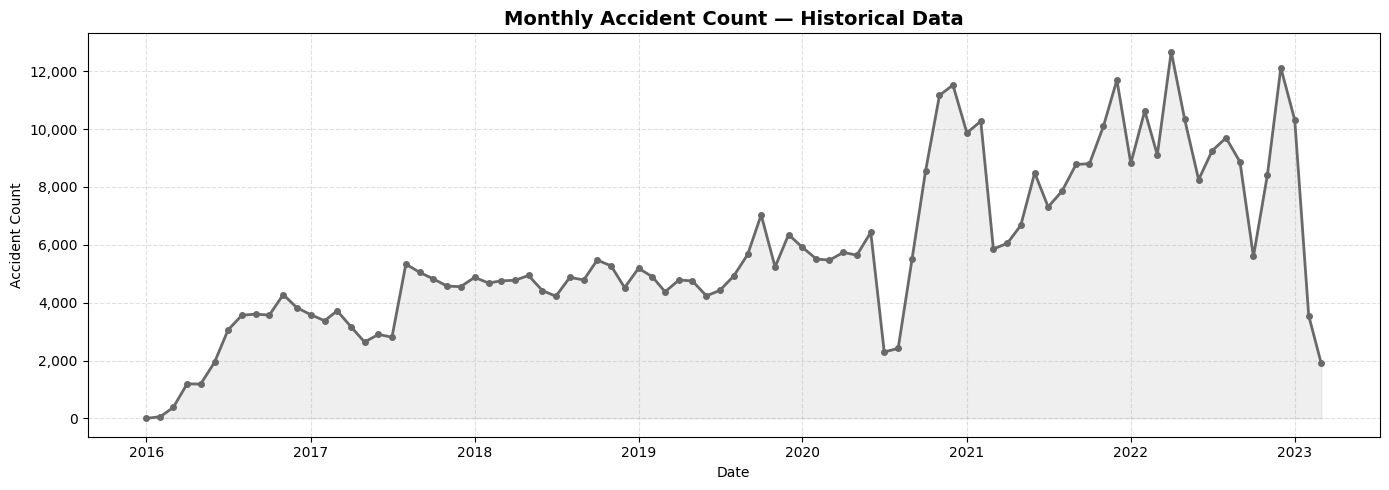

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['ds'], monthly['y'], color=MAIN_GRAY, linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly['ds'], monthly['y'], color=MAIN_GRAY, alpha=0.1)
ax.set_title("Monthly Accident Count — Historical Data", fontsize=14, fontweight='bold')
ax.set_xlabel("Date"); ax.set_ylabel("Accident Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show(); plt.close()

## 4. Train Prophet Model

In [4]:
# Prophet model with seasonality
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,   # monthly data — no weekly
    daily_seasonality=False,    # monthly data — no daily
    seasonality_mode='multiplicative',  # better for count data
    changepoint_prior_scale=0.05,       # controls trend flexibility
    interval_width=0.95                 # 95% confidence interval
)

# Add US holidays effect
model.add_country_holidays(country_name='US')

model.fit(monthly)
print("Prophet model trained successfully!")

16:29:20 - cmdstanpy - INFO - Chain [1] start processing
16:29:21 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully!


## 5. Generate Forecast — Next 12 Months

In [5]:
# Create future dates — 12 months ahead
future = model.make_future_dataframe(periods=12, freq='MS')  # MS = Month Start

# Predict
forecast = model.predict(future)

# Show forecast
forecast_future = forecast[forecast['ds'] > monthly['ds'].max()][
    ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
].copy()
forecast_future.columns = ['Date', 'Predicted', 'Lower_Bound', 'Upper_Bound']
forecast_future['Predicted']    = forecast_future['Predicted'].clip(lower=0).astype(int)
forecast_future['Lower_Bound']  = forecast_future['Lower_Bound'].clip(lower=0).astype(int)
forecast_future['Upper_Bound']  = forecast_future['Upper_Bound'].clip(lower=0).astype(int)

print("Forecast for next 12 months:")
print(forecast_future.to_string(index=False))

Forecast for next 12 months:
      Date  Predicted  Lower_Bound  Upper_Bound
2023-04-01      13046        10110        16079
2023-05-01       9880         6945        12589
2023-06-01       6731         3766         9983
2023-07-01       8878         6071        11877
2023-08-01      10480         7412        13410
2023-09-01      10464         7610        13266
2023-10-01       9873         6963        12712
2023-11-01      10547         7470        13631
2023-12-01      14414        11317        17555
2024-01-01      12965        10161        15965
2024-02-01       8213         5267        11196
2024-03-01       8952         6145        11773


## 6. Plot Forecast

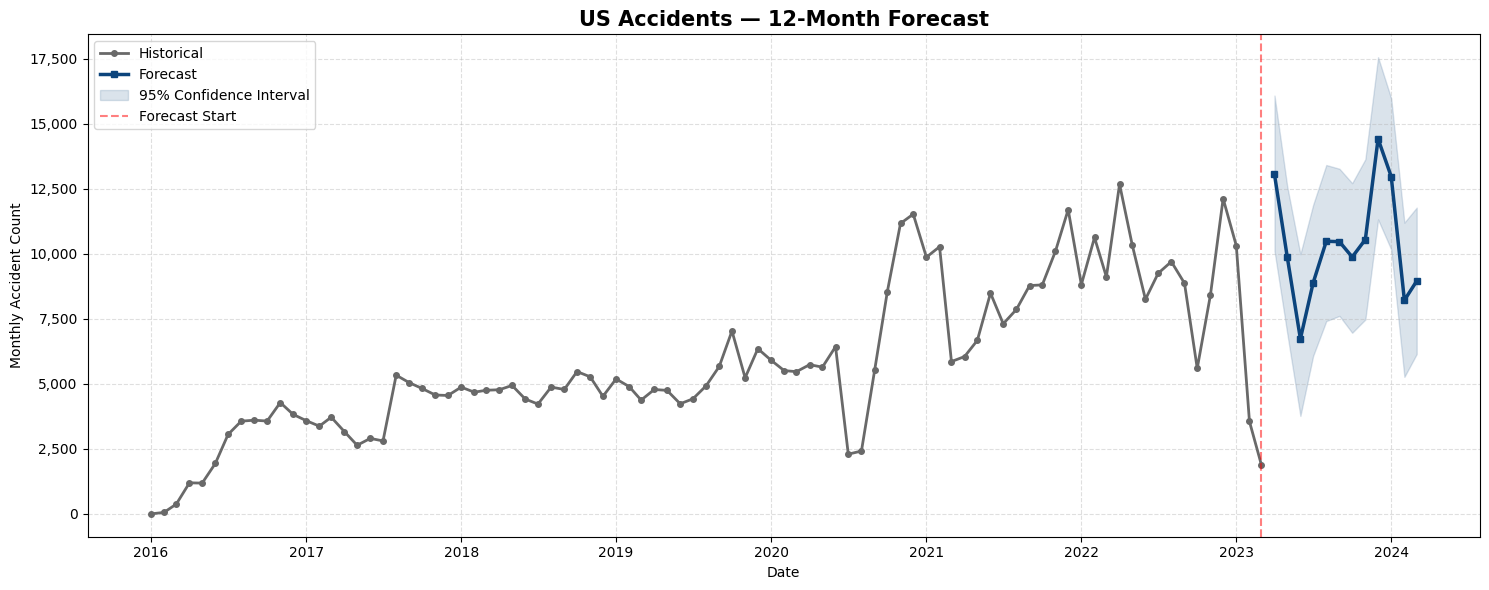

In [6]:
fig, ax = plt.subplots(figsize=(15, 6))

# Historical
ax.plot(monthly['ds'], monthly['y'],
        color=MAIN_GRAY, linewidth=2, marker='o', markersize=4, label='Historical')

# Forecast
future_mask = forecast['ds'] > monthly['ds'].max()
ax.plot(forecast.loc[future_mask, 'ds'],
        forecast.loc[future_mask, 'yhat'].clip(lower=0),
        color='#0C447C', linewidth=2.5, marker='s', markersize=5, label='Forecast')

# Confidence interval
ax.fill_between(
    forecast.loc[future_mask, 'ds'],
    forecast.loc[future_mask, 'yhat_lower'].clip(lower=0),
    forecast.loc[future_mask, 'yhat_upper'].clip(lower=0),
    color='#0C447C', alpha=0.15, label='95% Confidence Interval'
)

# Divider line
ax.axvline(monthly['ds'].max(), color='red', linestyle='--', alpha=0.5, label='Forecast Start')

ax.set_title("US Accidents — 12-Month Forecast", fontsize=15, fontweight='bold')
ax.set_xlabel("Date"); ax.set_ylabel("Monthly Accident Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend(loc='upper left'); ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show(); plt.close()

## 7. Plot Trend & Seasonality Components

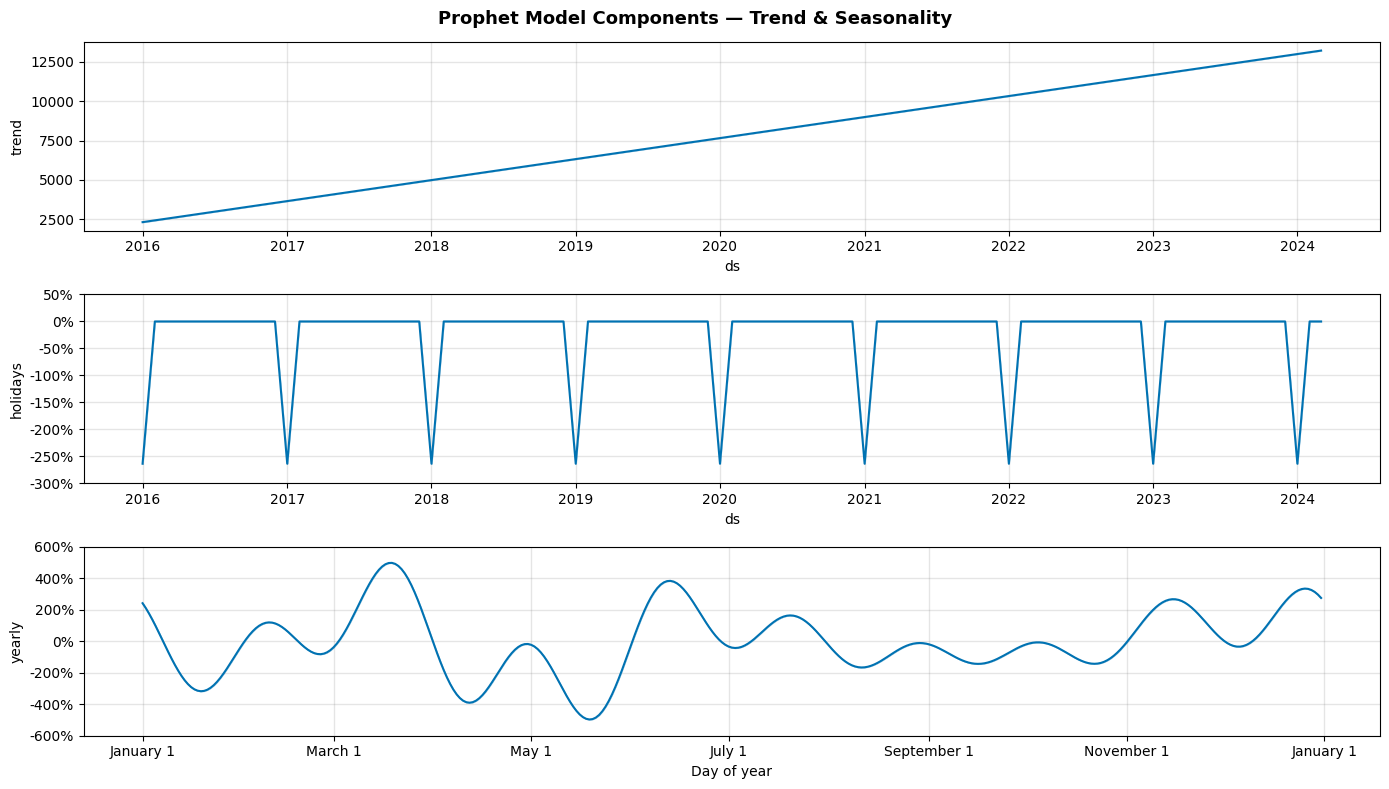

In [7]:
fig = model.plot_components(forecast)
fig.set_size_inches(14, 8)
plt.suptitle("Prophet Model Components — Trend & Seasonality", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show(); plt.close()

## 8. Model Evaluation — Cross Validation

In [8]:
from prophet.diagnostics import cross_validation, performance_metrics

# Cross validation — last 6 months as test
df_cv = cross_validation(
    model,
    initial='730 days',   # training period
    period='30 days',     # forecast every 30 days
    horizon='90 days',    # predict 90 days ahead
    parallel='processes'
)

metrics = performance_metrics(df_cv)
print("Model Performance Metrics:")
print(f"  MAE  (Mean Absolute Error)   : {metrics['mae'].mean():,.0f} accidents/month")
print(f"  RMSE (Root Mean Square Error): {metrics['rmse'].mean():,.0f} accidents/month")
print(f"  MAPE (Mean Absolute % Error) : {metrics['mape'].mean()*100:.1f}%")
print(f"  Accuracy                     : {(1 - metrics['mape'].mean())*100:.1f}%")

Model Performance Metrics:
  MAE  (Mean Absolute Error)   : 1,957 accidents/month
  RMSE (Root Mean Square Error): 2,454 accidents/month
  MAPE (Mean Absolute % Error) : 34.9%
  Accuracy                     : 65.1%


## 9. Severity-wise Forecast

16:29:34 - cmdstanpy - INFO - Chain [1] start processing
16:29:34 - cmdstanpy - INFO - Chain [1] done processing
16:29:35 - cmdstanpy - INFO - Chain [1] start processing
16:29:35 - cmdstanpy - INFO - Chain [1] done processing
16:29:35 - cmdstanpy - INFO - Chain [1] start processing
16:29:35 - cmdstanpy - INFO - Chain [1] done processing
16:29:36 - cmdstanpy - INFO - Chain [1] start processing
16:29:36 - cmdstanpy - INFO - Chain [1] done processing


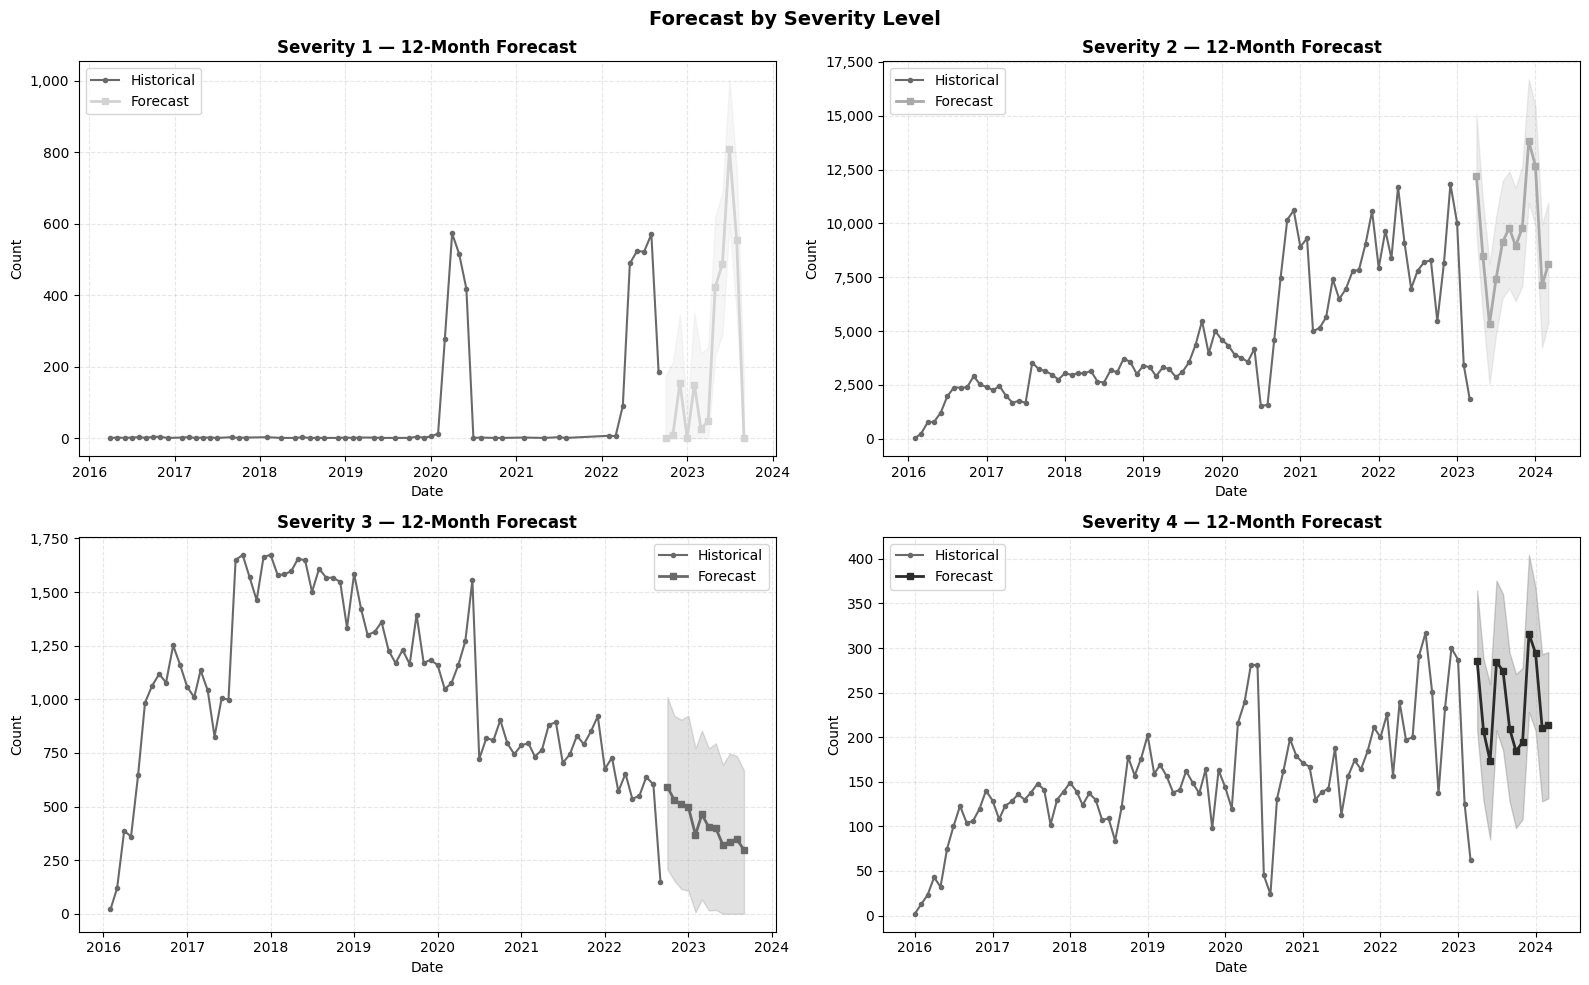

Severity-wise forecasts complete!


In [9]:
# Forecast each Severity level separately
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
colors = ['#d3d3d3', '#a9a9a9', '#696969', '#2C2C2A']

severity_forecasts = {}

for i, sev in enumerate([1, 2, 3, 4]):
    # Filter by severity
    df_sev = df[df['Severity'] == sev].copy()
    df_sev['Start_Date'] = pd.to_datetime(
        df_sev['Year'].astype(str) + '-' +
        df_sev['Month'].astype(str).str.zfill(2) + '-01')
    monthly_sev = df_sev.groupby('Start_Date').size().reset_index(name='count')
    monthly_sev.columns = ['ds', 'y']
    monthly_sev = monthly_sev.sort_values('ds')

    # Train Prophet
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                daily_seasonality=False, seasonality_mode='multiplicative',
                interval_width=0.95, changepoint_prior_scale=0.05)
    m.fit(monthly_sev)

    # Forecast
    future_sev = m.make_future_dataframe(periods=12, freq='MS')
    fc_sev = m.predict(future_sev)
    severity_forecasts[sev] = fc_sev

    # Plot
    ax = axes[i]
    future_mask = fc_sev['ds'] > monthly_sev['ds'].max()
    ax.plot(monthly_sev['ds'], monthly_sev['y'],
            color=MAIN_GRAY, linewidth=1.5, marker='o', markersize=3, label='Historical')
    ax.plot(fc_sev.loc[future_mask,'ds'],
            fc_sev.loc[future_mask,'yhat'].clip(lower=0),
            color=colors[i], linewidth=2, marker='s', markersize=4, label='Forecast')
    ax.fill_between(fc_sev.loc[future_mask,'ds'],
                    fc_sev.loc[future_mask,'yhat_lower'].clip(lower=0),
                    fc_sev.loc[future_mask,'yhat_upper'].clip(lower=0),
                    color=colors[i], alpha=0.2)
    ax.set_title(f"Severity {sev} — 12-Month Forecast", fontsize=12, fontweight='bold')
    ax.set_xlabel("Date"); ax.set_ylabel("Count")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
    ax.legend(); ax.grid(linestyle='--', alpha=0.3)

plt.suptitle("Forecast by Severity Level", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show(); plt.close()
print("Severity-wise forecasts complete!")

## 10. Save Forecast Results

In [10]:
import os
os.makedirs('Gold_Layer', exist_ok=True)

# Save main forecast
forecast_save = forecast[['ds','yhat','yhat_lower','yhat_upper']].copy()
forecast_save.columns = ['Date','Predicted','Lower_Bound','Upper_Bound']
forecast_save['Predicted']   = forecast_save['Predicted'].clip(lower=0).round(0).astype(int)
forecast_save['Lower_Bound'] = forecast_save['Lower_Bound'].clip(lower=0).round(0).astype(int)
forecast_save['Upper_Bound'] = forecast_save['Upper_Bound'].clip(lower=0).round(0).astype(int)
forecast_save['Is_Forecast'] = (forecast_save['Date'] > monthly['ds'].max()).astype(int)
forecast_save.to_csv('Gold_Layer/Prophet_Forecast.csv', index=False)

print(f"Saved: Gold_Layer/Prophet_Forecast.csv ({len(forecast_save)} rows)")
print(f"  Historical rows : {(forecast_save['Is_Forecast']==0).sum()}")
print(f"  Forecast rows   : {(forecast_save['Is_Forecast']==1).sum()}")
print()
print("Next 12 months prediction:")
next12 = forecast_save[forecast_save['Is_Forecast']==1]
for _, row in next12.iterrows():
    print(f"  {row['Date'].strftime('%Y-%m')}: {row['Predicted']:,} accidents "
          f"(range: {row['Lower_Bound']:,} - {row['Upper_Bound']:,})")

Saved: Gold_Layer/Prophet_Forecast.csv (99 rows)
  Historical rows : 87
  Forecast rows   : 12

Next 12 months prediction:
  2023-04: 13,047 accidents (range: 10,110 - 16,080)
  2023-05: 9,881 accidents (range: 6,946 - 12,589)
  2023-06: 6,731 accidents (range: 3,766 - 9,984)
  2023-07: 8,879 accidents (range: 6,071 - 11,878)
  2023-08: 10,480 accidents (range: 7,413 - 13,411)
  2023-09: 10,464 accidents (range: 7,611 - 13,267)
  2023-10: 9,874 accidents (range: 6,963 - 12,712)
  2023-11: 10,548 accidents (range: 7,471 - 13,631)
  2023-12: 14,415 accidents (range: 11,317 - 17,556)
  2024-01: 12,966 accidents (range: 10,162 - 15,966)
  2024-02: 8,213 accidents (range: 5,267 - 11,196)
  2024-03: 8,953 accidents (range: 6,145 - 11,774)
